***Estrutucuración del proyecto***

*Instalar y desplegar librerias*

In [2]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn plotly jupyter


  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached notebook-7.5.5-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.0-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.5.6-py3-none-any.whl.metadata (16 kB)
  Using cached async_lru-2.2.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_lsp-2.3.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\andre\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
# Manejo de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
# Utilidades
import warnings
warnings.filterwarnings('ignore')


*Leer archivos*

In [2]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
No encontrado: Marzo-2026.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Noviembre-2025', 'Diciembre-2025', 'Enero-2026', 'Febrero-2026']
Facturas 

*Verificar fechas de los acrhivos*

In [3]:
col_fecha = "Fecha elaboración"
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")



Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Noviembre-2025: 2025-11-04 → 2025-11-30
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28


*Crear un df unificado*

In [4]:
df_total = pd.concat(productos.values(), ignore_index=True)


*Concatenar df de ventas por lugar*

In [5]:

#Concatenar en caso de tener mas datos
CP_df=factura_lugar["CP-2025"]
Principal_df=factura_lugar["Principal-2025"]

#Poner el lugar en cada df
CP_df["Lugar"]="CP"
Principal_df["Lugar"]="Principal"

#Unificar todo en un solo df
df_place=pd.concat([CP_df,Principal_df],ignore_index=True)



*Ver que datos tiene cada df*

In [6]:
col1=set(df_total.columns)
col2=set(df_place.columns)

#Mirar intersescciones
print(col1 - col2)#Esta en  total
print(col2 - col1)#Esta en places
print(col2 & col1)#Esta en ambos


{'Fecha vencimiento', 'Impuesto Cargo 2', 'Valor Impuesto Cargo 2', 'Referencia fábrica', 'Forma pago', 'Nombre', 'Fecha elaboración', 'Impuesto cargo', 'Valor Impuesto Cargo', 'Valor Impuesto Retención', 'Identificación', 'Nombre vendedor', 'Nombre contacto', 'Cantidad', 'Observaciones', 'Bodega', 'Correo electrónico', 'Consecutivo', 'Sucursal', 'Valor desc.', 'Nombre tercero', 'Tasa de cambio', 'Base AIU', 'Código', 'Cargo en totales', 'Tipo de registro', 'Centro costo', 'Fecha creación', 'Impuesto retención', 'Identificación Vendedor', 'Descuento en totales', 'Factura proveedor', 'Tipo transacción', 'Base retención (ICA/IVA)', 'Tipo clasificación', 'Número comprobante', 'Valor unitario', 'Fecha modificación'}
{'Tarjetas', 'Fecha y hora', 'Tipo de comprobante', 'Otros', 'Cliente', 'Efectivo', 'Vendedor', 'Crédito', 'Lugar', 'Pagos en línea', 'Estado', 'Turno', 'Nro. de comprobante', 'Nro. de identificación'}
{'Total'}


*Adaptar datos por factura*

In [7]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Principal",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


*Poner fecha en formato datetime*

In [8]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


*Poner como se pago cada transacción y otras cosas*

In [9]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


In [10]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


In [11]:
ventas=df_ventas_producto_filtrado
ventas.rename(columns={"Fecha creación":"Fecha"},inplace=True)
ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal
...,...,...,...,...,...,...,...,...,...,...,...,...
32080,896.0,2026-02-02,16,Bowl Colombianito Mediana,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Nequí,FV-4,CP
32081,896.0,2026-02-02,27,Ensalada Chefsito Grande,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Nequí,FV-4,CP
32082,896.0,2026-02-02,79,Americano Mediano,Juan Jose Yara Vallejo,2.0,4166.66,666.67,9000.0,Nequí,FV-4,CP
32083,896.0,2026-02-02,21025,Mexi,Juan Jose Yara Vallejo,1.0,18500.00,0.00,18500.0,Nequí,FV-4,CP


In [12]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


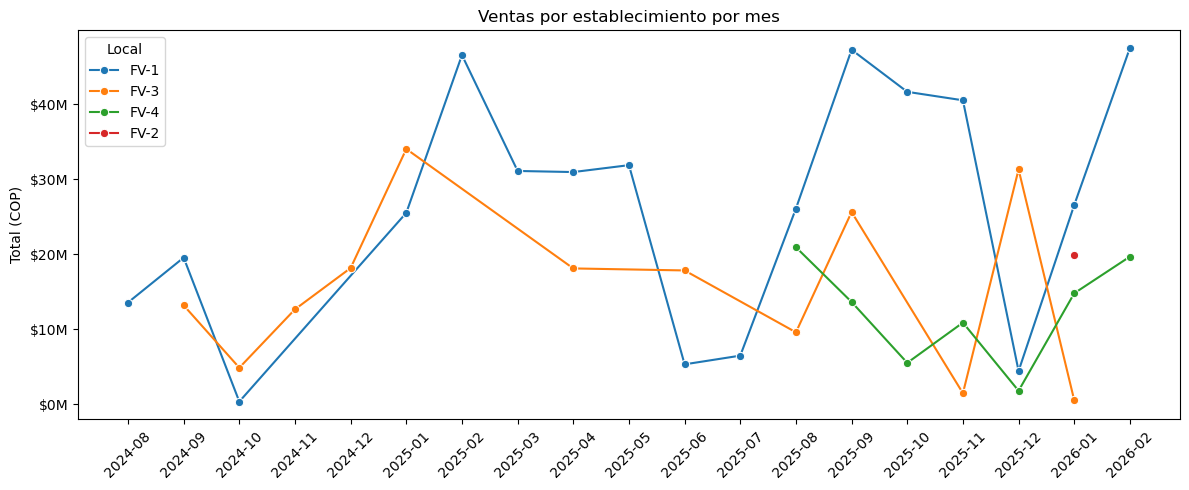

In [13]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


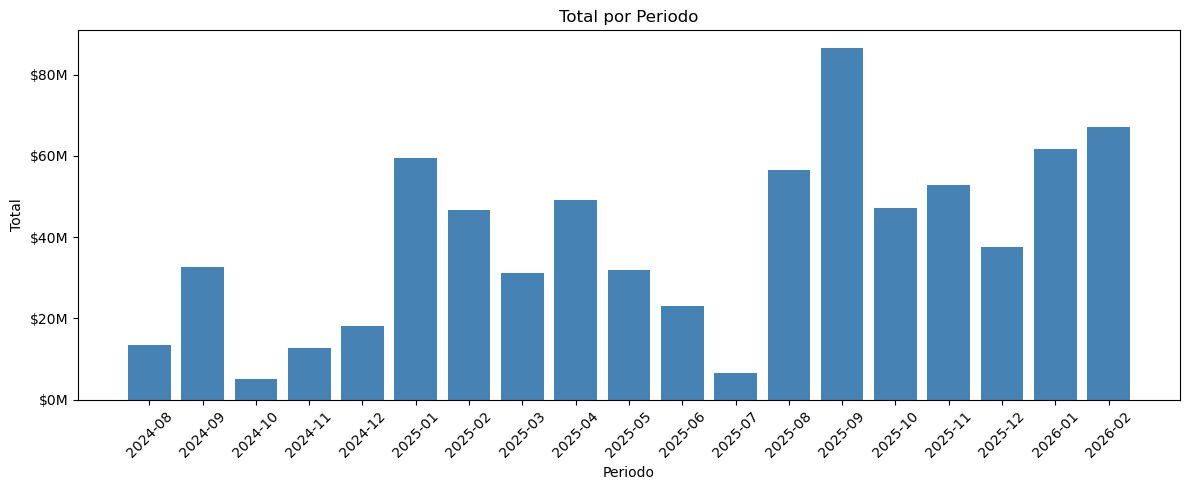

In [14]:
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(resumen_mes["Periodo"], resumen_mes["Total"], color="steelblue")
plt.title("Total por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


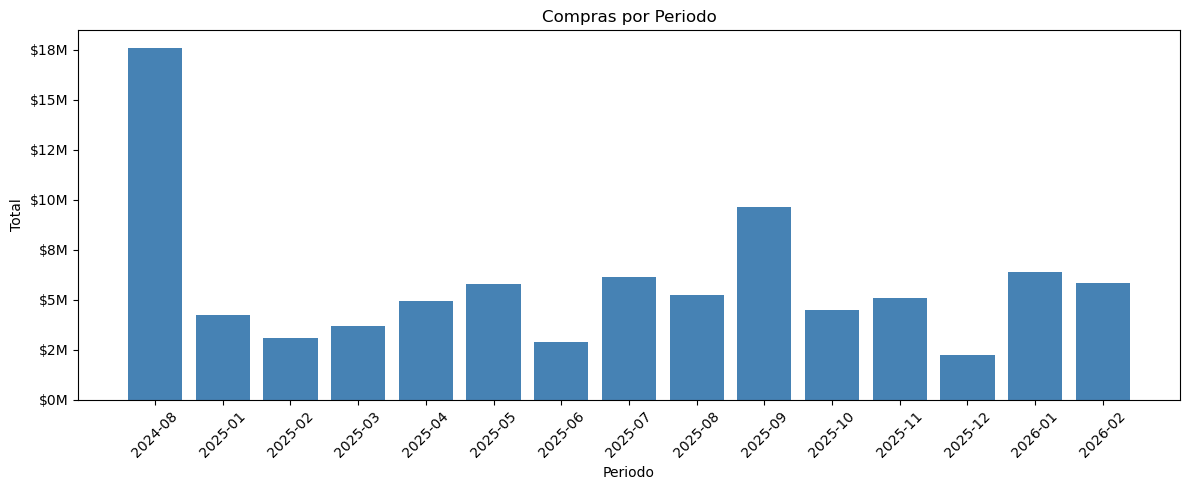

In [15]:
compras = df_compras_producto_filtrado.copy()
compras["Periodo"] = pd.to_datetime(compras["Fecha elaboración"]).dt.to_period("M")

resumen_compras_mes = compras.groupby("Periodo")["Total"].sum().reset_index()
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
plt.bar(resumen_compras_mes["Periodo"], resumen_compras_mes["Total"], color="steelblue")
plt.title("Compras por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


In [16]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-11   52863172.00      5109383.0  47753789.00
16  2025-12   37505122.90      2227879.0  35277243.90
17  2026-01   61709036.00   

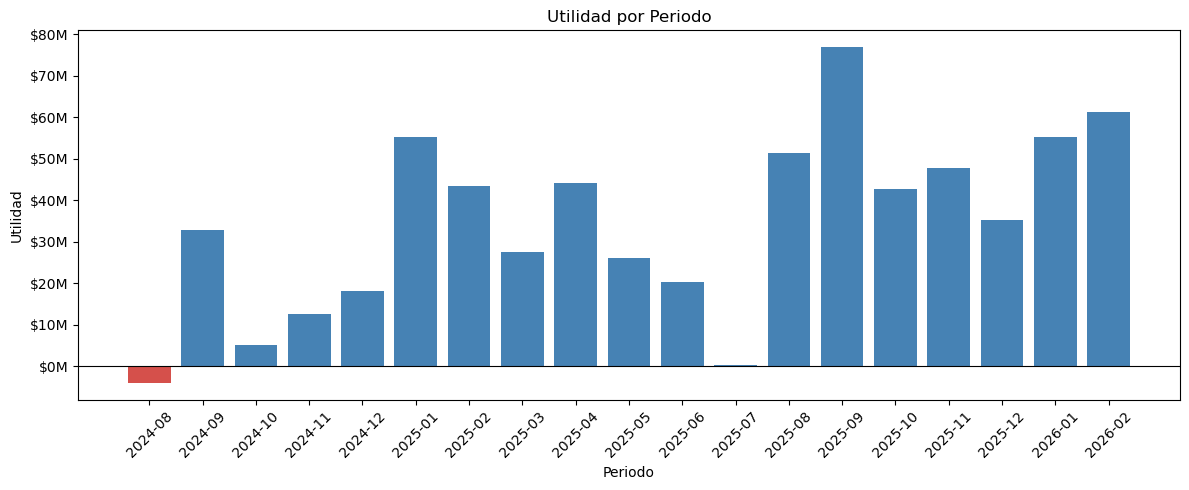

In [17]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


# Organizar dataset para el modelo

In [18]:
ventas_p=ventas[(ventas["Establecimiento"]=="Principal")&(ventas["Fecha"]>="2025-01-01")].sort_values("Fecha",ascending=True).reset_index()
dataset_p=ventas_p[["Fecha","Nombre","Cantidad","Total"]]


In [19]:
info_productos = dataset_p.groupby("Nombre").apply(lambda x: pd.Series({
    "transacciones": x["Nombre"].count(),
    "cantidad_total": x["Cantidad"].sum(),
    "precio_promedio": x["Total"].sum() / x["Cantidad"].sum(),
    "Plata generada":x["Total"].sum()
    
})).sort_values("transacciones", ascending=False)


In [20]:
# Definimos los puntos de corte
corte_x = info_productos["cantidad_total"].median()
corte_y = info_productos["Plata generada"].median()

# Función para asignar el color/categoría
def clasificar(row):
    if row["cantidad_total"] >= corte_x and row["Plata generada"] >= corte_y:
        return "ESTRELLA (Alto Vol / Alto $)"
    elif row["cantidad_total"] < corte_x and row["Plata generada"] >= corte_y:
        return "PREMIUM (Bajo Vol / Alto $)"
    elif row["cantidad_total"] >= corte_x and row["Plata generada"] < corte_y:
        return "GANCHO (Alto Vol / Bajo $)"
    else:
        return "BAJO DESEMPEÑO"

# Aplicamos la lógica al DataFrame
info_productos["Categoria_Matriz"] = info_productos.apply(clasificar, axis=1)


import plotly.express as px

fig = px.scatter(
    info_productos.reset_index(), 
    x="cantidad_total", 
    y="Plata generada",
    color="Categoria_Matriz",  # Los colores se asignan por cuadrante
    color_discrete_map={       # Colores estratégicos
        "ESTRELLA (Alto Vol / Alto $)": "#2ecc71",   # Verde
        "PREMIUM (Bajo Vol / Alto $)": "#3498db",    # Azul
        "GANCHO (Alto Vol / Bajo $)": "#f1c40f",    # Amarillo
        "BAJO DESEMPEÑO": "#e74c3c"                  # Rojo
    },
    hover_name="Nombre",
    log_x=True, 
    log_y=True,
    hover_data=["precio_promedio", "transacciones"],
    title="Dashboard de Estrategia de Productos",
    template="plotly_white"
)

# Ajustes estéticos finales
fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.add_vline(x=corte_x, line_dash="dot", line_color="gray", opacity=0.5)
fig.add_hline(y=corte_y, line_dash="dot", line_color="gray", opacity=0.5)

fig.update_layout(
    legend_title_text='Categoría de Negocio',
    font=dict(family="Verdana", size=12)
)

fig.show()


*Ver que productos generan mas*

In [ ]:
info_productos=info_productos.reset_index()


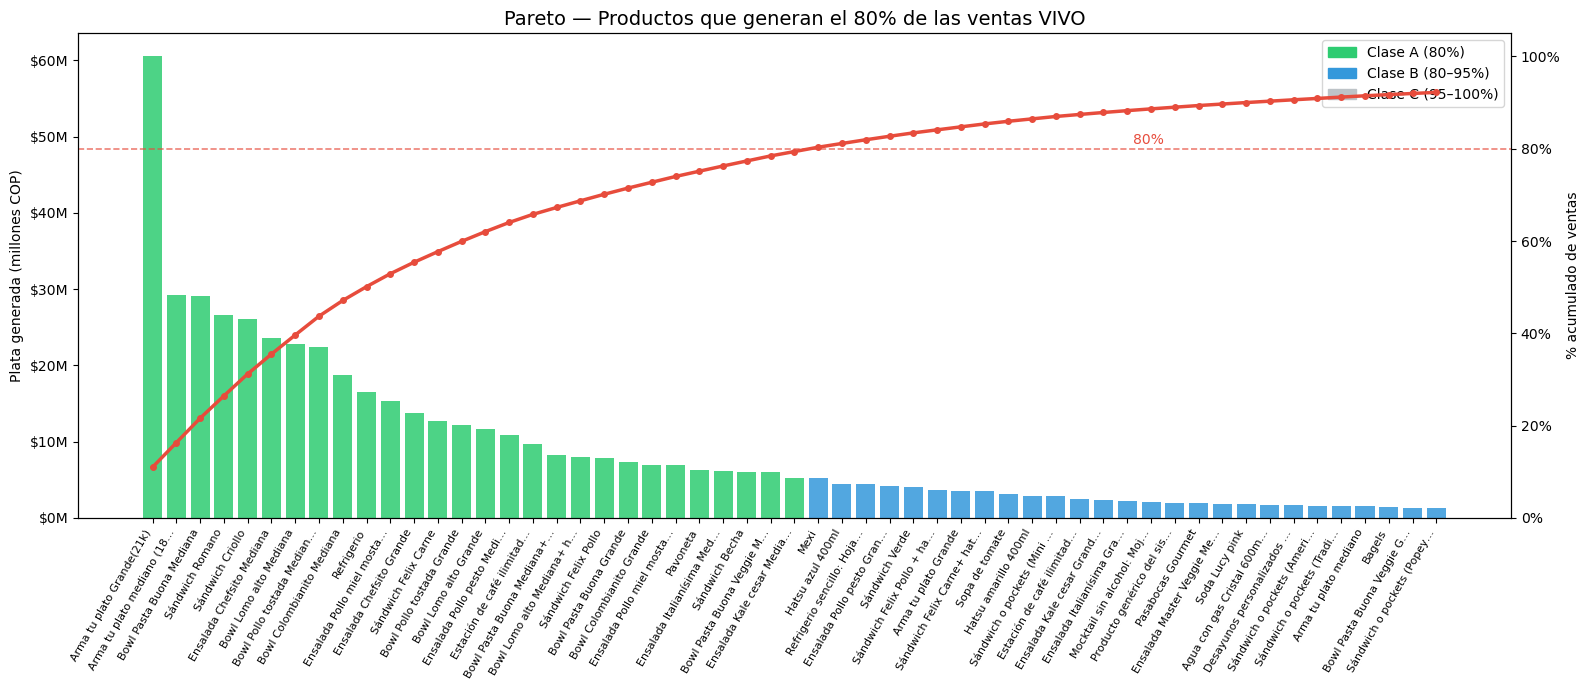


Resumen ABC:
Clase_ABC
C    159
B     42
A     28
Name: count, dtype: int64

Productos Clase A: 28
Plata generada Clase A: $436,956,363


In [ ]:
# ── PASO 1: ordenar PRIMERO ───────────────────────────────────────
info_productos = info_productos.sort_values('Plata generada', ascending=False).reset_index(drop=True)

# ── PASO 2: calcular pct DESPUÉS de ordenar ───────────────────────
total = info_productos['Plata generada'].sum()
info_productos['pct']      = info_productos['Plata generada'] / total
info_productos['pct_acum'] = info_productos['pct'].cumsum()

# ── PASO 3: clasificar ABC ────────────────────────────────────────
condiciones = [
    info_productos['pct_acum'] <= 0.80,
    info_productos['pct_acum'] <= 0.95,
]
info_productos['Clase_ABC'] = np.select(condiciones, ['A', 'B'], default='C')

# ── PASO 4: graficar ──────────────────────────────────────────────
n_mostrar = min(55, len(info_productos))
df_plot   = info_productos.head(n_mostrar)

colores = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

fig, ax1 = plt.subplots(figsize=(16, 7))

# Barras — plata generada
ax1.bar(range(n_mostrar), df_plot['Plata generada'] / 1_000_000, color=colores, alpha=0.85)
ax1.set_ylabel('Plata generada (millones COP)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))

# Línea acumulada (eje derecho)
ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)
ax2.set_ylabel('% acumulado de ventas')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Etiquetas eje X
nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

# Leyenda
leyenda = [
    Patch(color='#2ecc71', label='Clase A (80%)'),
    Patch(color='#3498db', label='Clase B (80–95%)'),
    Patch(color='#bdc3c7', label='Clase C (95–100%)'),
]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Pareto — Productos que generan el 80% de las ventas VIVO', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nResumen ABC:")
print(info_productos['Clase_ABC'].value_counts())
print(f"\nProductos Clase A: {(info_productos['Clase_ABC'] == 'A').sum()}")
print(f"Plata generada Clase A: ${info_productos[info_productos['Clase_ABC']=='A']['Plata generada'].sum():,.0f}")


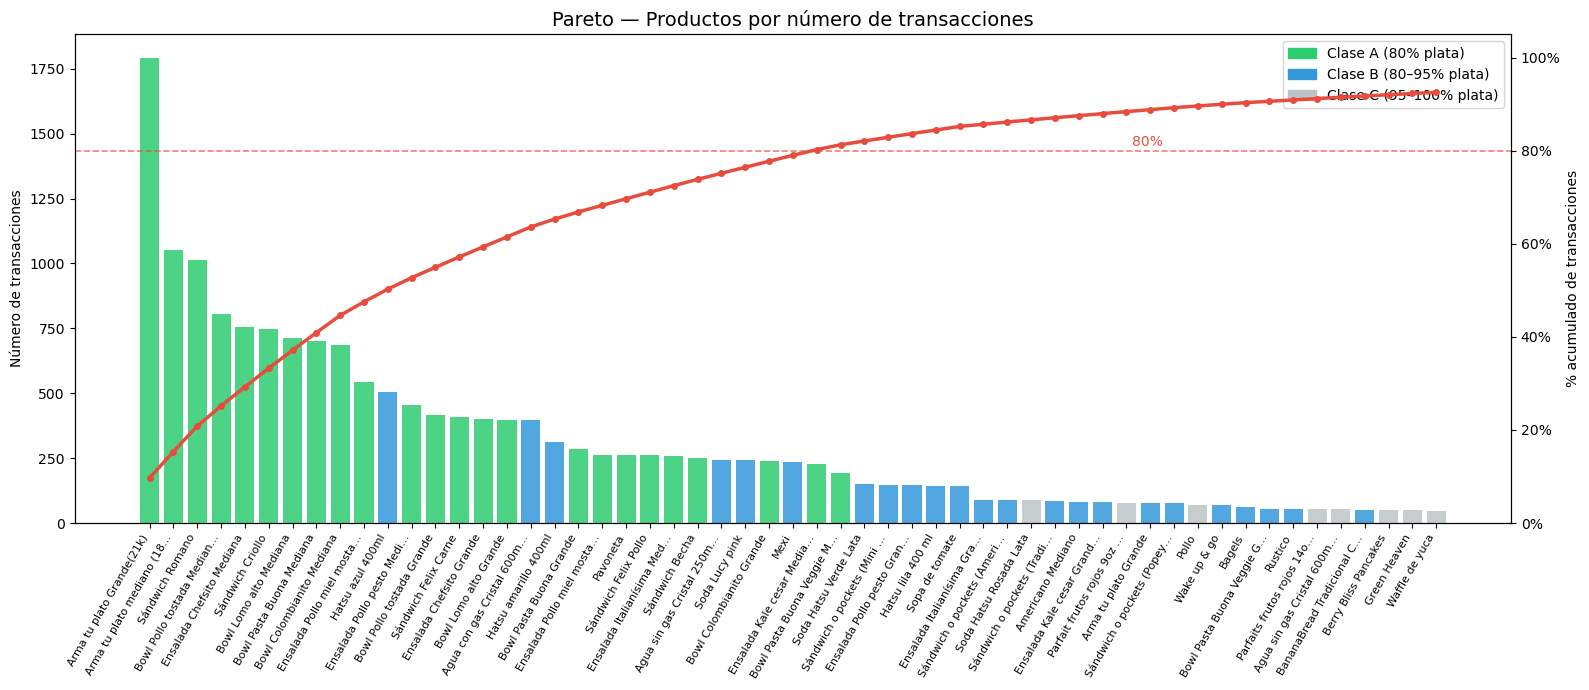

In [ ]:
# ── GRÁFICO 2: ordenado por transacciones ────────────────────────
df_trans = info_productos.sort_values('transacciones', ascending=False).reset_index(drop=True)
df_trans['pct_trans']      = df_trans['transacciones'] / df_trans['transacciones'].sum()
df_trans['pct_trans_acum'] = df_trans['pct_trans'].cumsum()

n_mostrar = min(55, len(df_trans))
df_plot   = df_trans.head(n_mostrar).copy()
colores   = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(range(n_mostrar), df_plot['transacciones'], color=colores, alpha=0.85)
ax1.set_ylabel('Número de transacciones')

ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_trans_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)
ax2.set_ylabel('% acumulado de transacciones')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

leyenda = [Patch(color='#2ecc71', label='Clase A (80% plata)'), Patch(color='#3498db', label='Clase B (80–95% plata)'), Patch(color='#bdc3c7', label='Clase C (95–100% plata)')]
ax1.legend(handles=leyenda, loc='upper right')
plt.title('Pareto — Productos por número de transacciones', fontsize=14)
plt.tight_layout()
plt.show()
